In [1]:
from pyfiles.ftsteane import *
from HPC.Upload.classes import *
from random import choices
import itertools

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Bitstream Vera Sans",
    "font.sans-serif": "Helvetica",
})

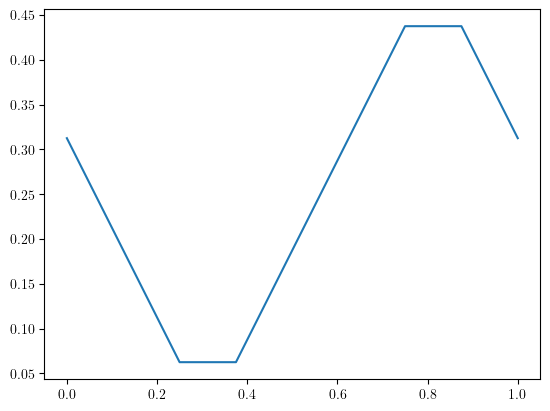

In [2]:
n = 15
angle = np.linspace(0,1,n+2)
angle = np.delete(angle, [n+1])
angle = np.delete(angle, [0])

input = angle[4]

bits = np.linspace(0,1,9)

def diff(output):
    return min(np.abs(input-output), 1-np.abs(input-output))

y =  [diff(i) for i in bits]

plt.plot(bits, y)

In [3]:
ok, errr, y_list = avg15_repcode("z", 3, 3, 0.005, qec = False, post=False, k = 3, bias = -10000)          

print(y_list, "\n", np.mean(y_list), np.std(y_list))

Amount of gates in this circuit:  4855
QEC counter: 0
Amount of gates in this circuit:  2516
QEC counter: 0
Amount of gates in this circuit:  1368
QEC counter: 0
Performance for angle 0:  0.8125
Amount of gates in this circuit:  5299
QEC counter: 0
Amount of gates in this circuit:  2695
QEC counter: 0
Amount of gates in this circuit:  1393
QEC counter: 0
Performance for angle 1:  0.125
Amount of gates in this circuit:  4855
QEC counter: 0
Amount of gates in this circuit:  2516
QEC counter: 0
Amount of gates in this circuit:  1325
QEC counter: 0
Performance for angle 2:  0.4375
Amount of gates in this circuit:  631
QEC counter: 0
Amount of gates in this circuit:  404
QEC counter: 0
Amount of gates in this circuit:  269
QEC counter: 0
Performance for angle 3:  0.125
Amount of gates in this circuit:  4855
QEC counter: 0
Amount of gates in this circuit:  2473
QEC counter: 0
Amount of gates in this circuit:  1282
QEC counter: 0
Performance for angle 4:  0.3125
Amount of gates in this circui

In [10]:
ok, errr, y_list = avg15_repcode("z", 3, 3, 0.005, qec = True, post=False, k = 3, bias = -10000)       

print(y_list, "\n", np.mean(y_list), np.std(y_list))

Amount of gates in this circuit:  10087
QEC counter: 654
Amount of gates in this circuit:  5113
QEC counter: 330
Amount of gates in this circuit:  2626
QEC counter: 168
Performance (QEC) for angle 0:  0.4375
Amount of gates in this circuit:  11011
QEC counter: 714
Amount of gates in this circuit:  5575
QEC counter: 360
Amount of gates in this circuit:  2857
QEC counter: 183
Performance (QEC) for angle 1:  0.375
Amount of gates in this circuit:  10087
QEC counter: 654
Amount of gates in this circuit:  5113
QEC counter: 330
Amount of gates in this circuit:  2626
QEC counter: 168
Performance (QEC) for angle 2:  0.1875
Amount of gates in this circuit:  1255
QEC counter: 78
Amount of gates in this circuit:  697
QEC counter: 42
Amount of gates in this circuit:  509
QEC counter: 30
Performance (QEC) for angle 3:  0.0
Amount of gates in this circuit:  10087
QEC counter: 654
Amount of gates in this circuit:  5204
QEC counter: 336
Amount of gates in this circuit:  2808
QEC counter: 180
Performan

In [ ]:
mapping = {
    "s": "s_x",
    "sdg": "sdg_x",
    "t": "t_x",
    "tdg": "tdg_x"
}

def transform(lst):
    new_lst = []
    i = 0

    while i < len(lst):
        # Look for h followed by one of the target symbols
        if i < len(lst) - 1 and lst[i] == "h" and lst[i + 1] in mapping:
            new_lst.append(mapping[lst[i + 1]])
            new_lst.append("h")
            i += 2  # Skip both elements since we've handled them
        else:
            new_lst.append(lst[i])
            i += 1

    return new_lst

input_file = "HPC/Upload/adjunitary15.txt"
output_file = "adjunitary15_repz.txt"

new_lines = []

with open(input_file, "r") as f:
    for line in f:
        lst = line.strip().split(",")
        new_lines.append(transform(lst))

with open(output_file, "w") as f:
    for lst in new_lines:
        f.write(",".join(lst) + "\n")

In [2]:
dustin = RepCode_z(3, 2)

gates(dustin.qc)

dustin.h(0)
dustin.h(0)


gates(dustin.qc)

dustin.qc = transpile(dustin.qc, optimization_level=1)

gates(dustin.qc)


dustin.readout(0, 1000, 0.00, bias = -1000)


print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)
print("Postselection: ", dustin.post)

Amount of gates in this circuit:  48
Amount of gates in this circuit:  90
Amount of gates in this circuit:  78
Zeros:  1.0
Ones:  0.0
Postselection:  0.0


In [ ]:
p = np.linspace(0, 0.005, 5)
y, err, y1, err1 = [], [], [], []
for i in p:  
    a, b = avg15_repcode(3, 3, i, qec = False, k = 5, bias = -0.5)
    c, d = avg15_repcode(3, 3, i, qec = True, k = 5, bias = -0.5)

    y.append(a), err.append(b),
    y1.append(c), err1.append(d)

In [ ]:
plt.plot(p, y, label="No QEC")
plt.plot(p, y1, label="With QEC")  
plt.grid()
plt.legend()

In [ ]:
dustin = Steane7q(1, 1)

dustin.h(0)
dustin.tdg_switch(0)
dustin.t_switch(0)
dustin.h(0)

dustin.readout(0,1000,0)

print("Postselected: ", dustin.post)
print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)

In [ ]:
y, err = avg15_coin("steane", 1, 0, True, 1)
print(y, err)

In [ ]:
dustin = RotSurf9q_test(2)

dustin.h(0)
dustin.t_cheat(0)
dustin.h(0)

# dustin.testing_magic(0)

dustin.readout(0,100,0)

print("Postselected: ", dustin.post)
print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)

In [ ]:
qc = QuantumCircuit(3,3)

qc.ry(np.pi/4,0)
#qc.y(0)
########################Controlled-Hadamard Injection##################################
qc.h(2)

qc.cx(0,1)
qc.h(1)
qc.cx(1,0)
qc.h(1)

qc.x(2)
qc.ry(-np.pi/4, 1)
qc.cz(2, 1)
qc.ry(np.pi/4, 1)
qc.x(2)

qc.measure(1,0)         #anc

with qc.if_test((0,0)): #anc
    qc.cx(2,0)

with qc.if_test((0,1)): #anc
    qc.x(0)
    qc.z(0)
    qc.cx(2,0)
    qc.z(2)
##########################################################
qc.h(0)


read = ClassicalRegister(1)
qc.add_register(read)

qc.measure(0,read[0])

sim = AerSimulator()
job = sim.run(qc, shots=10000)
result = job.result()
counts = result.get_counts()

bitstring = list(counts.keys())
bitstring = [i.replace(" ","") for i in bitstring]
hmm = list(counts.values())

bit = [i[0] for i in bitstring]

zero, one = 0, 0

for i in range(len(bit)):
    if bit[i] == "0":
        zero += hmm[i]
    else:
        one += hmm[i]

print("0:", zero)
print("1:", one)

In [ ]:
qc = QuantumCircuit(3,1)

qc.x(0)

qc.cx(0,1)
qc.h(1)
qc.cx(1,0)
qc.h(1)

qc.measure(1,0)         #anc

with qc.if_test((0,0)):
    qc.x(0)
with qc.if_test((0,1)):
    qc.z(0)

qc.h(0)

qc.measure(0,0)

sim = AerSimulator()
job = sim.run(qc, shots=1000)
result = job.result()
counts = result.get_counts()

print(counts)

In [ ]:
# avg_15_coin_circ(0, 0, [], False, path="", name="9q_angle0")

In [ ]:
dustin = RotSurf9q(n=2, magic=0)

dustin.postselection = True

dustin.testing_magic(0)
# dustin.qec(0)
# dustin.qec(0)
# dustin.h(0)

dustin.magic_readout(0,1000,0)                 
print("Preselection: ", dustin.preselected)
print("Postselected: ", dustin.post)
print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)

print("Selected Zeros: ", dustin.zeros/(dustin.ones + dustin.zeros))
print("Selected Ones: ", dustin.ones/(dustin.ones + dustin.zeros))

In [ ]:
dustin = RotSurf9q(n=2, magic=1)

dustin.postselection = True

dustin.h(0)
dustin.ft_s(0)
dustin.ft_s(0)
dustin.h(0)

dustin.readout(0,1000,0)
print("Preselection: ", dustin.preselected)
print("Postselected: ", dustin.post)
print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)

In [ ]:
dustin = Steane7q(1,0)

dustin.postselection = True

# dustin.x(0)
# dustin.h(0)
dustin.rx_cheat(np.pi/4,0)
# dustin.h(0)

dustin.readout(0,1000,0)
print("Preselection: ", dustin.preselected)
print("Postselected: ", dustin.post)
print("Zeros: ", dustin.zeros)
print("Ones: ", dustin.ones)

In [ ]:
n = 15
angle = np.linspace(0,1,n+2)
angle = np.delete(angle, [n+1])
angle = np.delete(angle, [0])
print(angle)

In [ ]:
n = 15
angle = np.linspace(0,1,n+2)
angle = np.delete(angle, [n+1])
angle = np.delete(angle, [0])

print(angle)

neighbours = [closest_bitstring(i, 3) for i in angle]
print(neighbours)

fake = [convert(i) for i in neighbours]

print(fake)

In [ ]:
y = avg14_coin_success("steane", 3, noise=0.00, qec=False, k=1)

print(y)

In [ ]:
T_alt = np.diag([1, (1+1j)/np.sqrt(2), (1+1j)/np.sqrt(2), 1,
            (1+1j)/np.sqrt(2), 1, 1, (1+1j)/np.sqrt(2),
            (1+1j)/np.sqrt(2), 1, 1, (1+1j)/np.sqrt(2),
            1, (1+1j)/np.sqrt(2), (1+1j)/np.sqrt(2), 1])
        #threshold = 1e-10
        #T_alt[np.abs(T_alt) < threshold] = np.nan
t_timo = UnitaryGate(T_alt, label="t_timo")

In [ ]:
qc = QuantumCircuit(4)

qc.append(t_timo, [0, 1, 2, 3])

new_qc = transpile(qc, basis_gates=["h", "t", "cx"], optimization_level=3)

qc.draw("mpl")

new_qc.draw("latex")

In [ ]:
#x, y, y_qec, err, err_qec = [],[],[],[],[]
x1, y1, y_qec1, err1, err_qec1 = np.loadtxt("text/RotSurfFinal_a.txt", delimiter = ",")
x2, y2, y_qec2, err2, err_qec2 = np.loadtxt("text/RotSurfFinal_a+.txt", delimiter = ",")
x3, y3, y_qec3, err3, err_qec3 = np.loadtxt("text/RotSurfFinal_a++.txt", delimiter = ",")

x1, y1, y_qec1, err1, err_qec1 = list(x1), list(y1), list(y_qec1), list(err1), list(err_qec1)
x2, y2, y_qec2, err2, err_qec2 = list(x2), list(y2), list(y_qec2), list(err2), list(err_qec2)
x3, y3, y_qec3, err3, err_qec3 = list(x3), list(y3), list(y_qec3), list(err3), list(err_qec3)

x2.pop(0), x3.pop(0), y2.pop(0), y3.pop(0), y_qec2.pop(0), y_qec3.pop(0), err2.pop(0), err3.pop(0), err_qec2.pop(0), err_qec3.pop(0)

# x = list(x1) + list(x2) + list(x3)
# y = list(y1) + list(y2) + list(y3)
# y_qec = list(y_qec1) + list(y_qec2) + list(y_qec3)
# err = list(err1) + list(err2) + list(err3)
# err_qec = list(err_qec1) + list(err_qec2) + list(err_qec3)
x = x1+x2+x3
y = y1+y2+y3
y_qec = y_qec1+y_qec2+y_qec3
err = err1+err2+err3
err_qec = err_qec1+err_qec2+err_qec3

data = np.array([x,y,y_qec,err,err_qec])
np.savetxt("text/RotSurfFinal_BA.txt", data, delimiter = ",")

fig, ax1 = plt.subplots(figsize=(7,5))
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals = 1))

err = [i/((400)**0.5) for i in err]
err_qec = [i/((400)**0.5)for i in err_qec]

ax1.plot(x,y_qec, label="QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(x,y, label="No QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y, yerr=err, ecolor="red", linestyle="")

ax1.set_title("3 Iterations, 15 angles, each 400 Shots", fontsize=25)

ax1.set_xlabel("Pauli Error probability", fontsize=25)

ax1.set_ylabel(r"$\Delta \varphi$", fontsize=25)

ax1.tick_params(axis='both', which='major', labelsize=25)

ax1.grid()
ax1.legend(fontsize=20)

#fig.suptitle('Three iterations iQPE on a [12,2,4] Carbon Code', fontsize=20)
plt.tight_layout()

#plt.savefig("Figures/RotSurfFinal_4.png", dpi = 200)
plt.show()

In [ ]:
#x, y, y_qec, err, err_qec = [],[],[],[],[]
x, y, y_qec, err, err_qec = np.loadtxt("Files für Leon/FTSteane_BA_PS_QEC+PS.txt", delimiter = ",")


fig, ax1 = plt.subplots(figsize=(7,5))
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals = 1))

err = [i/((400)**0.5) for i in err]
err_qec = [i/((400)**0.5)for i in err_qec]

ax1.plot(x,y_qec, label="QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(x,y, label="No QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y, yerr=err, ecolor="red", linestyle="")

ax1.set_title("3 Iterations, 15 angles, each 400 Shots", fontsize=25)

ax1.set_xlabel("Pauli Error probability", fontsize=25)

ax1.set_ylabel(r"$\Delta \varphi$", fontsize=25)

ax1.tick_params(axis='both', which='major', labelsize=25)

ax1.grid()
ax1.legend(fontsize=20)

#fig.suptitle('Three iterations iQPE on a [12,2,4] Carbon Code', fontsize=20)
plt.tight_layout()

#plt.savefig("Figures/RotSurfFinal_4.png", dpi = 200)
plt.show()

In [ ]:
x, y, y_qec, err, err_qec = np.loadtxt("Files für Leon/FTSteane_BA_PS_QEC+PS.txt", delimiter = ",")


fig, ax1 = plt.subplots(figsize=(7,5))
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals = 2))

err = [i/((400-113)**0.5) for i in err]
err_qec = [i/((400-113)**0.5)for i in err_qec]

ax1.plot(x,y_qec, label="QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(x,y, label="No QEC", marker = ".",markersize = 20, alpha = 0.5)
ax1.errorbar(x, y, yerr=err, ecolor="red", linestyle="")


ax1.set_title(r"3 Iterations, 15 angles, each $\sim$ 300 Shots, QEC after every $T/T^\dagger$", fontsize=20)

ax1.set_xlabel("Pauli Error probability", fontsize=25)

ax1.set_ylabel(r"$\Delta \varphi$", fontsize=25)

ax1.tick_params(axis='both', which='major', labelsize=25)

ax1.grid()
ax1.legend(fontsize=20)

#fig.suptitle('Three iterations iQPE on a [12,2,4] Carbon Code', fontsize=20)
plt.tight_layout()
#plt.savefig("Figures/SteaneFinal4.png", dpi = 200)
plt.show()